# References

In [1]:
%pip install pandas
%pip install matplotlib
%pip install scikit-learn
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 1. Preprocesamiento de Datos:

 - Cargar el dataset "wine quality dataset".
 - Realizar un análisis exploratorio inicial para entender las características de los datos, incluyendo estadísticas descriptivas y visualizaciones de las distribuciones de las características y la variable objetivo.
 - Limpiar y preparar los datos para el análisis, lo que puede incluir la gestión de valores faltantes y la normalización de variables numéricas.


In [2]:
import pandas as pd

# Importamos el dataset
data = pd.read_csv('WineQT.csv')

# Mostramos las primeras filas del dataset
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


Tenemos los distintos atributos del vino que están relacionados en mayor o menor medida con la calidad final del producto.  
  
Contamos únicamente con variables numéricas, no tenemos variables categóricas. Vemos que es necesario una normalización numérica para adecuar las escalas. La columna final, "id", no aporta información, podemos eliminarla. La variable objetivo es la calidad del vino, quality.

In [3]:
# Compobamos los valores nulos
data_clean = data.drop(columns=['Id'])
data_clean.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Como vemos no tenemos valores nulos, por lo tanto no es necesario aplicar técnicas para la gestión de valores faltantes.

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64


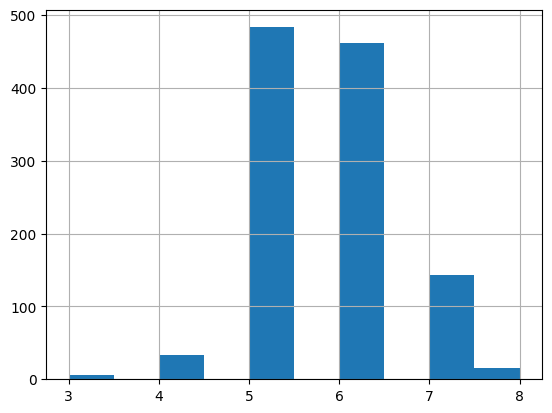

In [4]:
import matplotlib.pyplot as plt
# Mostramos el target
print(data_clean['quality'].value_counts())
data_clean['quality'].hist()
plt.show()

Tenemos 6 distintas calidades de vino, mantener las 6 clases nos puede generar problemas para la clasificación. Las clases estan desbalanceadas y las diferencias entre ellas no son demasiado grandes, esto puede provocar que confundamos con facilidad dos clases. Vamos a agrupar en 3 clases que dividan "malo", "medio" y "bueno".

quality
1    945
2    159
0     39
Name: count, dtype: int64


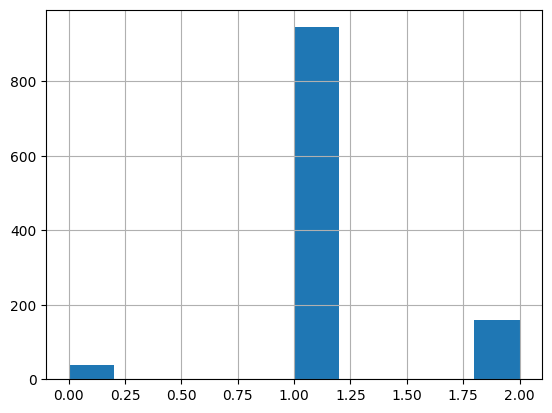

In [5]:
bins = [0, 4, 6, 10]
labels =  [0, 1, 2] # 0:malo, 1:medio, 2:bueno
data_clean['quality'] = pd.cut(data_clean['quality'], bins=bins, labels=labels)

print(data_clean['quality'].value_counts())
data_clean['quality'].hist()
plt.show()


In [6]:
# Normalizamos los datos
from sklearn.preprocessing import StandardScaler
data_characteristics = data_clean.drop(columns=['quality'])
data_target = data_clean['quality']

scaler = StandardScaler()
data_characteristics_scaled = scaler.fit_transform(data_characteristics)

Normalizamos las características usando el StandarScaler de seaborn que usa la media y la desviación estandar. Separamos el target para no modificarlo.

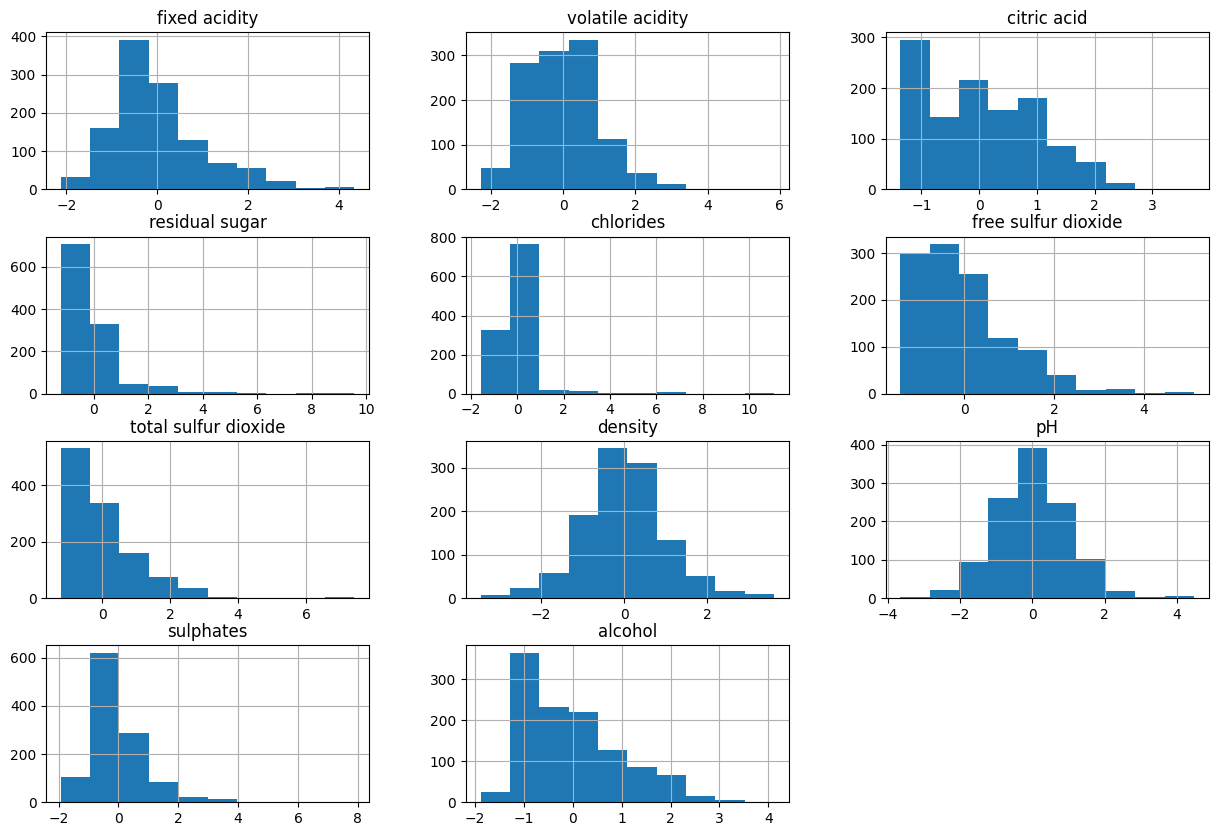

In [7]:
# Visualizamos la distribución de las características normalizadas
import matplotlib.pyplot as plt
data_characteristics_scaled_df = pd.DataFrame(data_characteristics_scaled, columns=data_characteristics.columns)

data_characteristics_scaled_df.hist(figsize=(15, 10))
plt.show()

# 2. Reducción de Dimensionalidad usando PCA:

 - Aplicar PCA (Análisis de Componentes Principales) para reducir la dimensionalidad del conjunto de datos.
 - Seleccionar el número de componentes principales necesarios para capturar una cantidad significativa de la variabilidad en los datos.
 - Transformar los datos a este nuevo espacio de características reducido.


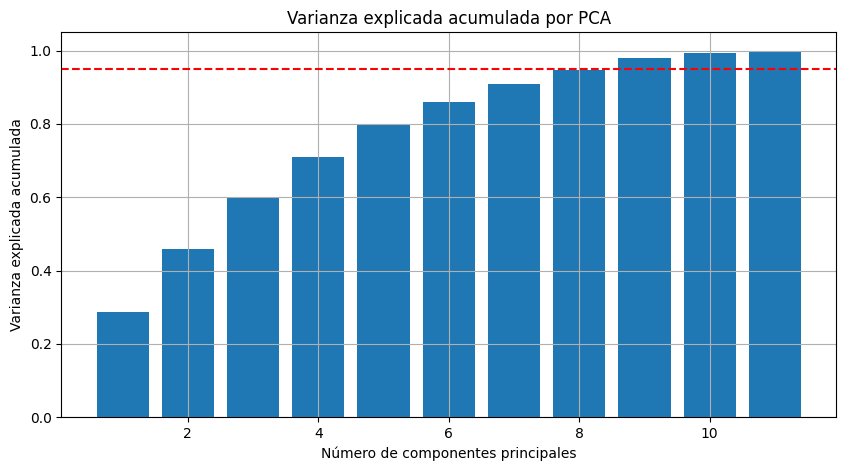

In [8]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
pca.fit(data_characteristics_scaled)

varianza = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(varianza) + 1), varianza)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada por PCA')
plt.grid()

Como vemos en la gráfica, para cubrir el 95% de varianza necesitamos como mínimo 8 componentes.

In [9]:
pca = PCA(n_components=8)
data_characteristics_pca = pca.fit_transform(data_characteristics_scaled)


# 3. Clasificación:

 - Utilizar dos clasificadores probabilísticos para modelar y predecir la variable objetivo.
 - Entrenar los modelos usando los datos transformados por PCA.


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Dividimos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    data_characteristics_pca, data_target, test_size=0.3, stratify=data_target
)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_predict = knn.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_predict = dt.predict(X_test)

# 4. Evaluación de Modelos:

 - Evaluar el rendimiento de cada modelo clasificador utilizando métricas como la precisión, la matriz de confusión, ...
 - Comparar los rendimientos de los dos clasificadores basándose en estas métricas.


In [11]:
knn_score = knn.score(X_test, y_test)
dt_score = dt.score(X_test, y_test)

print(f'KNN Accuracy: {knn_score:.2f}')
print(f'Decision Tree Accuracy: {dt_score:.2f}')

KNN Accuracy: 0.84
Decision Tree Accuracy: 0.81


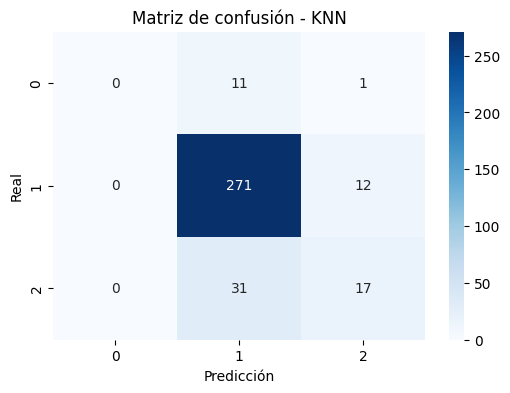

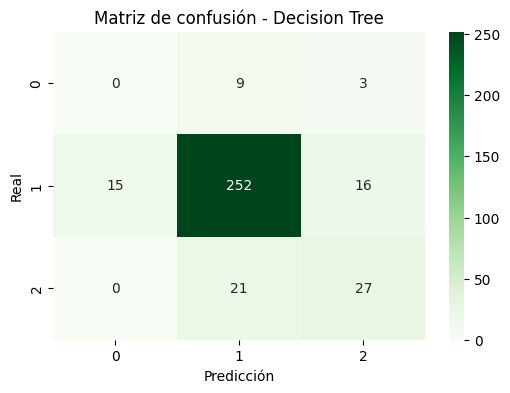

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.87      0.96      0.91       283
           2       0.57      0.35      0.44        48

    accuracy                           0.84       343
   macro avg       0.48      0.44      0.45       343
weighted avg       0.79      0.84      0.81       343

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.89      0.89      0.89       283
           2       0.59      0.56      0.57        48

    accuracy                           0.81       343
   macro avg       0.49      0.48      0.49       343
weighted avg       0.82      0.81      0.82       343



c:\Users\Johan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Johan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Johan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Matriz de confusión para KNN
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, knn_predict), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión - KNN')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Matriz de confusión para Decision Tree
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, dt_predict), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de confusión - Decision Tree')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Classification report
print("KNN Classification Report:\n", classification_report(y_test, knn_predict))
print("Decision Tree Classification Report:\n", classification_report(y_test, dt_predict))